In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import arviz as az
import json

In [3]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')
df_ont_T2 = pd.read_excel('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/20190412_MV_Bcellnumbers_ontogeny.xlsx', sheet_name='SPLEEN_Cell number')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Ontogeny Output/DDM/T2 Precursor/DDM_T2_LogisticGrowth_constantinflux.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_DDM = pkl.load(f)
else:
    raise EOFError("File is empty")

# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM_T2.pkl'
# if os.path.getsize(file_path) > 0:
#     with open(file_path, 'rb') as f:
#         data_SHM = pkl.load(f)
# else:
#     raise EOFError("File is empty")

# from cmdstanpy import from_csv
# data_neutral = from_csv(csv_files)
print(df_new.head(10))
print(df_ont.head(10))

                               Unnamed: 0  Age at BMT  Age at S1K  \
0  20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1  20181129_Bcells_SPLEEN_14d_002_020.fcs          74          88   
2      20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
3      20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
4        20181207_3wks_SPLEEN_001_048.fcs          74          95   
5        20181207_3wks_SPLEEN_002_049.fcs          41          62   
6        20181213_4wks_SPLEEN_001_024.fcs          74         102   
7        20181213_4wks_SPLEEN_002_025.fcs          41          69   
8   20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
9   20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   

   Days postBMT  Lamis ID      total_FM     fd_FM  frac_Ki67+_FM_donor  \
0            14    832634  2.247009e+07  0.016125             0.441377   
1            14    848687  2.440681e+07  0.013667             0.485563   
2            18   

In [4]:
file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM/SHM_T2_newsplines.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_SHM = pkl.load(f)
else:
    raise EOFError("File is empty")

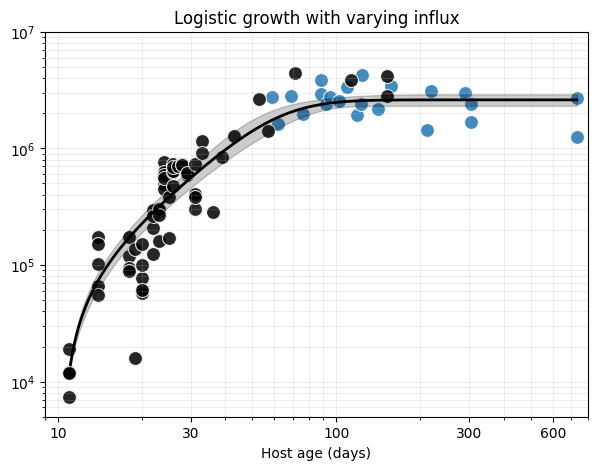

In [5]:
ts2= np.arange(11.1, 732.1, 0.1)
ts1= np.arange(59, 750, 1)
# ts1= np.arange(11, 152, 1)
# ts2 = np.arange(11, 153, 1)

# Plot the Mz counts
fig = plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Black',label='Young WT mice', legend=False)
# sns.scatterplot(data=df_ont_T2, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)

# plt.plot(ts1, np.mean(data_SHM.MZ_counts_pred1, axis=0))
# plt.fill_between(ts1, np.quantile(data_SHM.MZ_counts_pred1, 0.025, axis=0), np.quantile(data_SHM.MZ_counts_pred1, 0.975, axis=0), alpha=0.2, color = 'steelblue')
plt.plot(ts2, np.mean(data_DDM.MZ_counts_pred, axis=0), color='black', linewidth=2)
plt.fill_between(ts2, np.percentile(data_DDM.MZ_counts_pred, 2.5, axis=0), np.percentile(data_DDM.MZ_counts_pred, 97.5, axis=0), alpha=0.2, color='black')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(9, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
# plt.ylabel('Total MZ counts')
plt.title('Logistic growth with varying influx')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.legend(loc='lower right')
# plt.title('Logistic growth with varying death rate ')
#save figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Logistic_growth_constantinfluxwithcounts.png', dpi=300)

plt.show()



array([<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'phi'}>,
       <Axes: title={'center': 'kappa_0'}>,
       <Axes: title={'center': 'y0'}>], dtype=object)

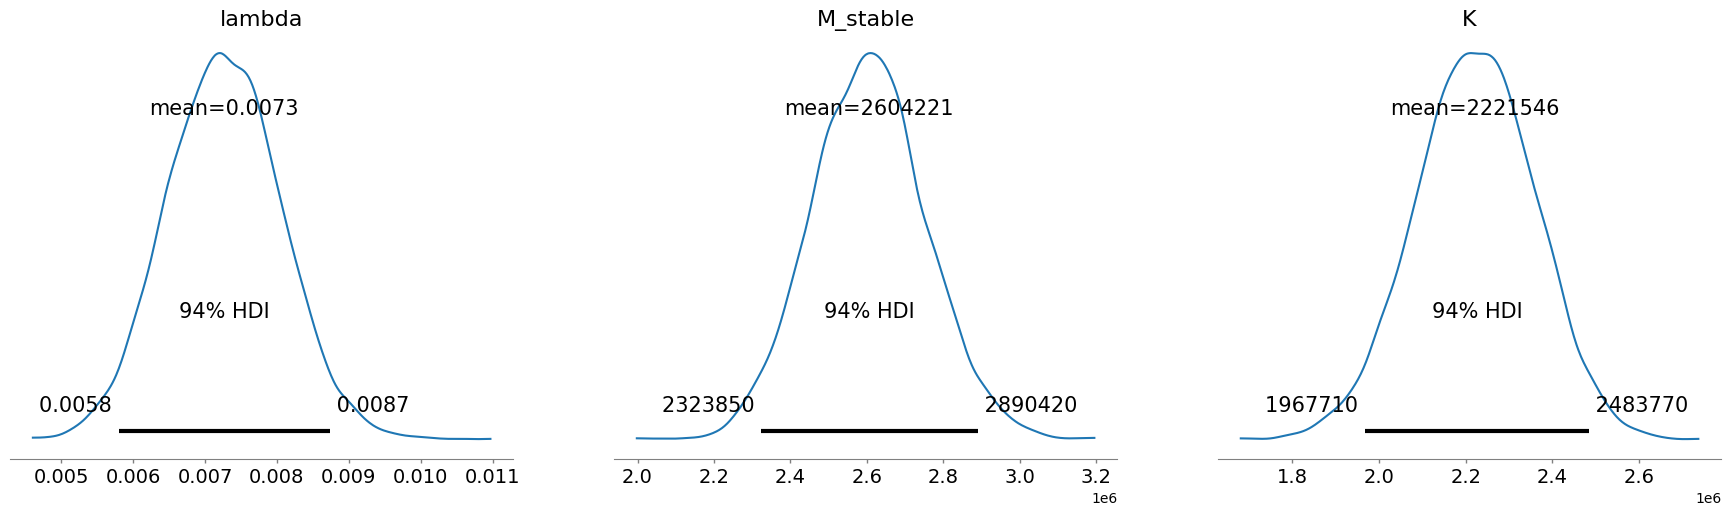

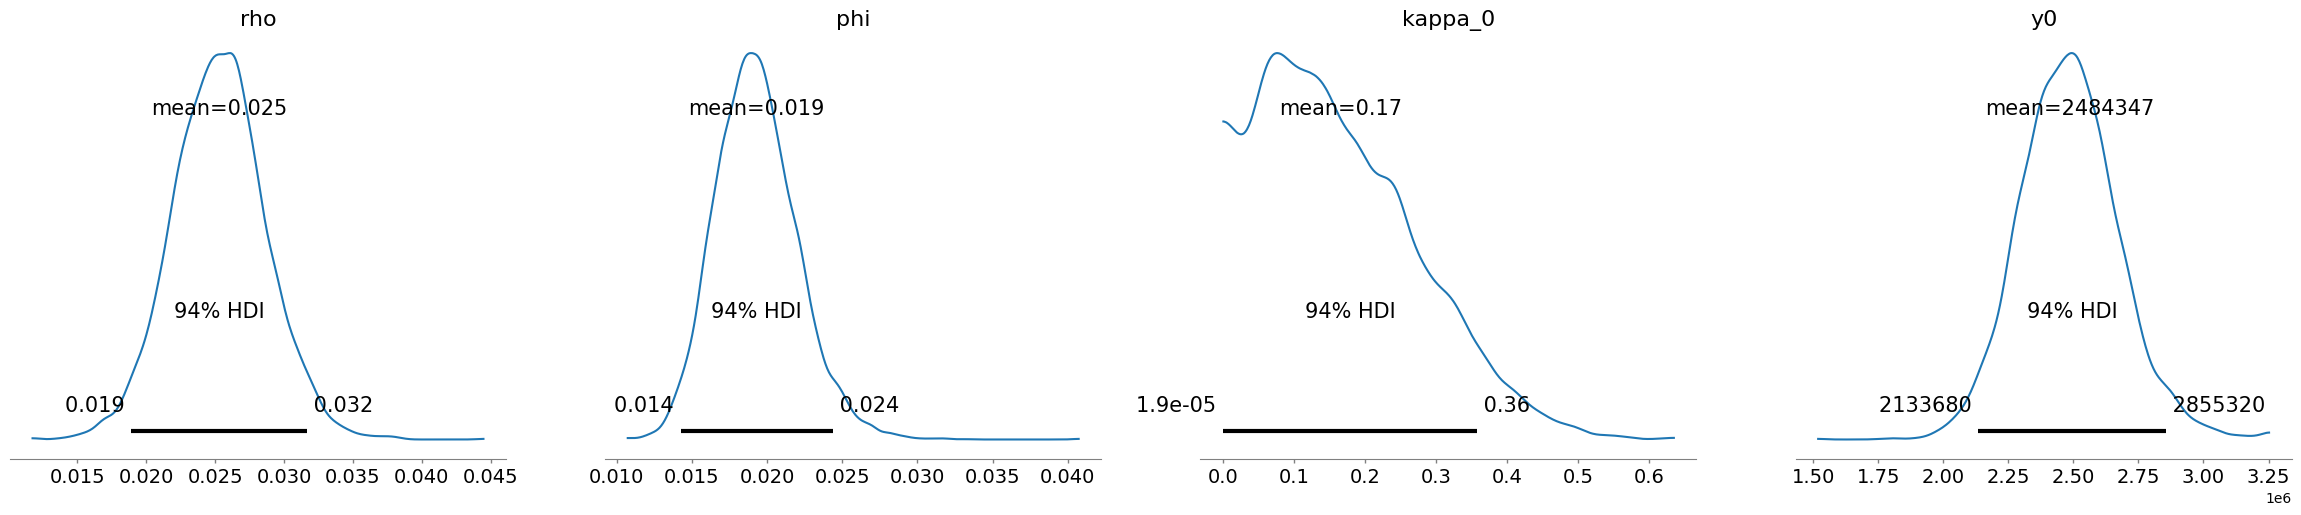

In [6]:
# Posterior distribution of parameters

# az.plot_posterior(data_neutral, var_names=['phi', 'r_phi','lambda'], kind='kde')
# az.plot_posterior(data_neutral, var_names=[ 'p', 'lambda','M_stable','K'], kind='kde')

az.plot_posterior(data_DDM, var_names=['lambda','M_stable','K'], kind='kde')
az.plot_posterior(data_SHM, var_names=['rho', 'phi', 'kappa_0', 'y0'], kind='kde')

# az.plot_posterior(data_neutral, var_names=['r_d', 't0'], kind='kde')



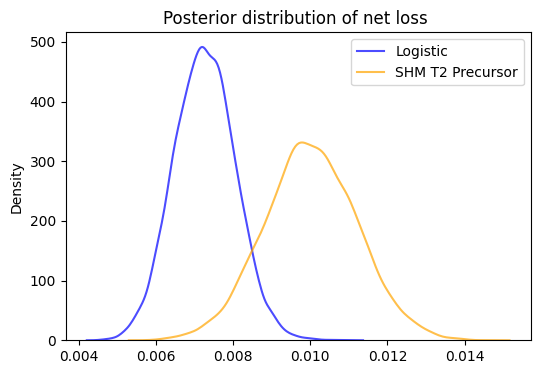

In [7]:
phi_samples = data_SHM.stan_variable('phi')
rho_samples = data_SHM.stan_variable('rho')
M_stable_samples = data_SHM.stan_variable('MZ_counts_pred1')
delta_samples = ((phi_samples * 1308516) / M_stable_samples[:,0] ) + rho_samples
# lambda_samples = delta_samples - rho_samples
lambda_samples = np.random.normal(0.01, 0.0012, 10000)
# Plot the posterior distribution for delta

fig, ax = plt.subplots(figsize=(6,4))

sns.kdeplot(data_DDM.stan_variable('lambda'), ax=ax, color='blue', alpha=0.7, label='Logistic')
sns.kdeplot(lambda_samples, ax=ax, color='orange', alpha=0.7, label='SHM T2 Precursor')
plt.title('Posterior distribution of net loss ')
plt.ylabel('Density')
plt.legend()
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Posterior_phi_DDM_T1_divisiondepnedent_vs_independent.pdf', dpi=300)
plt.show() 


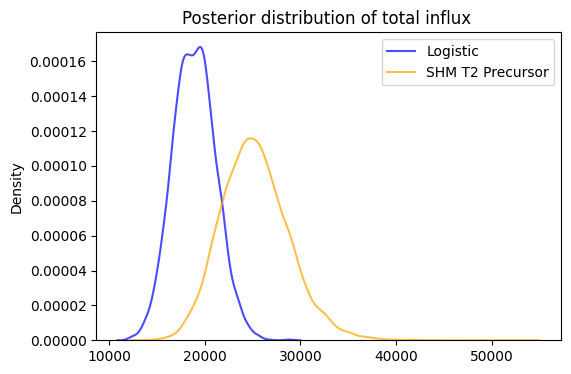

In [8]:
phi_samples = data_SHM.stan_variable('phi')
rho_samples = data_SHM.stan_variable('rho')
M_stable_samples = data_SHM.stan_variable('MZ_counts_pred1')
S_chimera = (phi_samples * 1308516)
# S_chimera = np.random.normal(2485012, 192154, 100000)
# lambda_samples = delta_samples - rho_samples
S_ont = data_DDM.stan_variable('lambda')*data_DDM.stan_variable('M_stable')
# Plot the posterior distribution for delta

fig, ax = plt.subplots(figsize=(6,4))

sns.kdeplot(S_ont, ax=ax, color='blue', alpha=0.7, label='Logistic')
sns.kdeplot(S_chimera, ax=ax, color='orange', alpha=0.7, label='SHM T2 Precursor')
plt.title('Posterior distribution of total influx ')
plt.ylabel('Density')
plt.legend()
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Posterior_phi_DDM_T1_divisiondepnedent_vs_independent.pdf', dpi=300)
plt.show() 

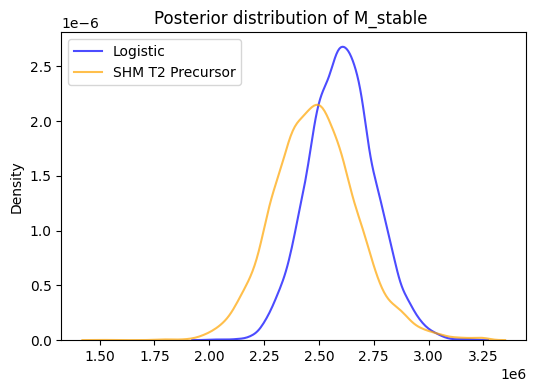

In [9]:
phi_samples = data_SHM.stan_variable('phi')
rho_samples = data_SHM.stan_variable('rho')
M_stable_samples = data_SHM.stan_variable('MZ_counts_pred1')

S_ont = data_DDM.stan_variable('lambda')*data_DDM.stan_variable('M_stable')
# Plot the posterior distribution for delta

fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(data_DDM.stan_variable('M_stable'), ax=ax, color='blue', alpha=0.7, label='Logistic')
sns.kdeplot(M_stable_samples[:,0], ax=ax, color='orange', alpha=0.7, label='SHM T2 Precursor')
plt.title('Posterior distribution of M_stable ')
plt.ylabel('Density')
plt.legend()
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Posterior_phi_DDM_T1_divisiondepnedent_vs_independent.pdf', dpi=300)
plt.show() 

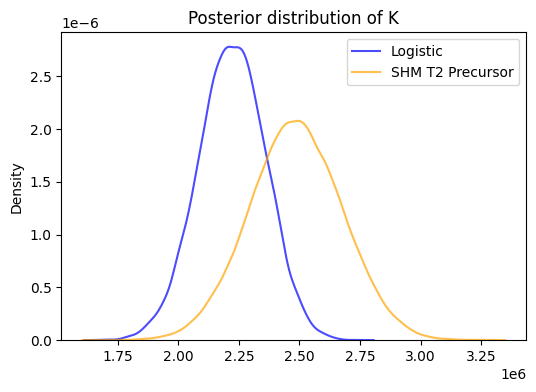

In [10]:
fig, ax = plt.subplots(figsize=(6,4))

k_prior= np.random.normal(2485012, 192154, 100000)
sns.kdeplot(data_DDM.stan_variable('K'), ax=ax, color='blue', alpha=0.7, label='Logistic')
sns.kdeplot(k_prior, ax=ax, color='orange', alpha=0.7, label='SHM T2 Precursor')
plt.title('Posterior distribution of K')
plt.ylabel('Density')
plt.legend()
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Posterior_phi_DDM_T1_divisiondepnedent_vs_independent.pdf', dpi=300)
plt.show() 

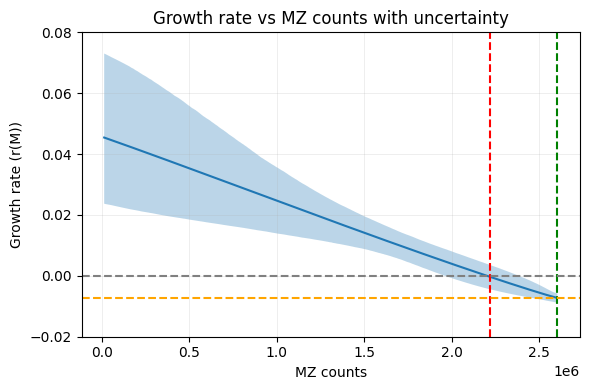

In [11]:
# Compute mean and quantiles
growth_mean = np.mean(data_DDM.source_rate, axis=0)
growth_lower = np.quantile(data_DDM.source_rate, 0.025, axis=0)
growth_upper = np.quantile(data_DDM.source_rate, 0.975, axis=0)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.plot(np.mean(data_DDM.MZ_counts_pred, axis=0), growth_mean)
axes.fill_between(np.mean(data_DDM.MZ_counts_pred, axis=0), growth_lower, growth_upper, alpha=0.3)
plt.axvline(x=np.mean(data_DDM.K, axis=0), color='red', linestyle='--', label='Carrying parameter (K)')
plt.axvline(x=np.mean(data_DDM.M_stable, axis=0), color='green', linestyle='--', label='Stable Population Size (M_stable)')
plt.axhline(y=-np.mean(data_DDM.stan_variable('lambda'), axis=0), color='orange', linestyle='--', label='Growth Rate')
plt.axhline(y=0, color='grey', linestyle='--')
axes.set_ylim(-0.02, 0.08)
axes.set_ylabel('Growth rate (r(M))')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Growth rate vs MZ counts with uncertainty')
plt.tight_layout()
plt.show()

0.04214785314896344
2221546.35


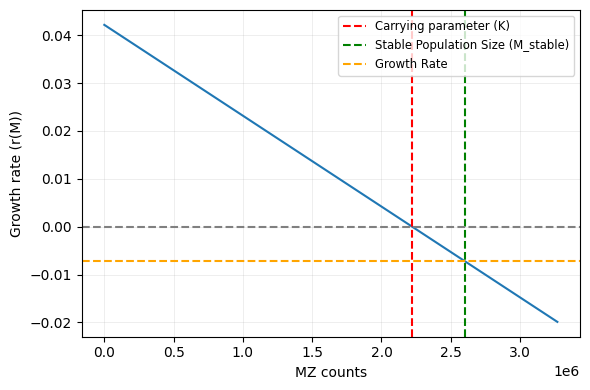

In [12]:
# Plot r(M) with respect to M 

# 'lambda' is a Python keyword so access via stan_variable to avoid syntax error
r = -np.mean(data_DDM.stan_variable('lambda'), axis=0) / (1 - (np.mean(data_DDM.M_stable, axis=0) / np.mean(data_DDM.K, axis=0)))
print(r)
def r_m(M):
    return r * (1 - (M / np.mean(data_DDM.K, axis=0)))

#cARRYING CAPACITY
K = np.mean(data_DDM.K, axis=0)
M = np.arange(0, np.exp(15), 1)

print(K)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.plot(M, r_m(M))
# Removed fill_between for quantiles since only mean is available
plt.axvline(x=np.mean(data_DDM.K, axis=0), color='red', linestyle='--', label='Carrying parameter (K)')
plt.axvline(x=np.mean(data_DDM.M_stable, axis=0), color='green', linestyle='--', label='Stable Population Size (M_stable)')
plt.axhline(y=-np.mean(data_DDM.stan_variable('lambda'), axis=0), color='orange', linestyle='--', label='Growth Rate')
plt.axhline(y=0, color='grey', linestyle='--')
axes.set_ylabel('Growth rate (r(M))')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.legend(loc='upper right', fontsize='small')
# axes.set_title('Total number of source cells into MZ (/day)')
plt.tight_layout()
plt.show()

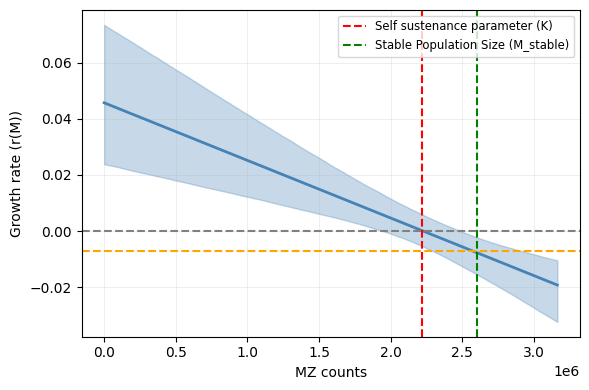

In [13]:
def r_m(M, lamda, M_stable, K):
    r = -(lamda) / (1 - (M_stable / K))
    return r * (1 - (M / K))

# M = np.arange(0, np.exp(15), 1)
M = np.logspace(3, 6.5, 1000)
lamda = data_DDM.stan_variable('lambda')
M_stable = data_DDM.M_stable
K = data_DDM.K

# Compute r_m for all posterior samples
# Reshape M to broadcast properly with posterior samples
M_broadcast = M[:, np.newaxis]  # Shape: (len(M), 1)
r_m_samples = r_m(M_broadcast, lamda, M_stable, K)  # Shape: (len(M), n_samples)

# Calculate statistics
r_m_mean = np.mean(r_m_samples, axis=1)
r_m_lower = np.percentile(r_m_samples, 2.5, axis=1)
r_m_upper = np.percentile(r_m_samples, 97.5, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.plot(M, r_m_mean, color='steelblue', linewidth=2)
axes.fill_between(M, r_m_lower, r_m_upper, alpha=0.3, color='steelblue')

plt.axvline(x=np.mean(K), color='red', linestyle='--', label='Self sustenance parameter (K)')
plt.axvline(x=np.mean(M_stable), color='green', linestyle='--', label='Stable Population Size (M_stable)')
plt.axhline(y=-np.mean(lamda), color='orange', linestyle='--')
plt.axhline(y=0, color='grey', linestyle='--')
axes.set_ylabel('Growth rate (r(M))')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()

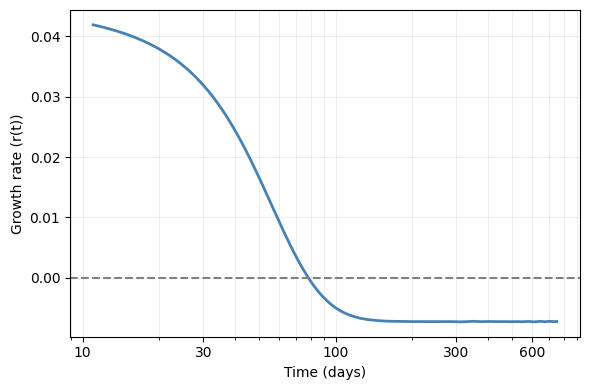

In [14]:
# Define the growth rate function in terms of M (avoid name clash with variable 'r')
def r_m_time(lamda, M, M_stable, K):
    """Instantaneous logistic growth rate r(M) given parameters."""
    r = -(lamda) / (1.0 - (M_stable / K))
    return r * (1.0 - (M / K))

# Define the ODE function with signature (t, y, *args) required by solve_ivp
def ode_function(t, y, S, lamda, M_stable, K):
    M_val = y[0]
    dMdt = S + r_m_time(lamda, M_val, M_stable, K) * M_val
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
lamda_mean = np.mean(data_DDM.stan_variable('lambda'))
M_stable_mean = np.mean(data_DDM.M_stable)
K_mean = np.mean(data_DDM.K)

# Compute S using posterior samples to get a representative mean source if desired
# This avoids mixing scalar means incorrectly.
S_samples = data_DDM.stan_variable('lambda') * data_DDM.M_stable
S_mean = np.mean(S_samples)

M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)

# Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
sol = solve_ivp(ode_function,
                [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(S_mean, lamda_mean, M_stable_mean, K_mean),
                vectorized=False)

if not sol.success:
    print("ODE solver failed:", sol.message)

# Extract solution and compute r(t)
M_t = sol.y[0]  # shape (len(t_ev),)
r_t = r_m_time(lamda_mean, M_t, M_stable_mean, K_mean)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.plot(t_ev, r_t, color='steelblue', linewidth=2)
plt.axhline(y=0, color='grey', linestyle='--')
# plt.axhline(y=-np.mean(data_DDM.stan_variable('lambda'), axis=0), color='orange', linestyle='--', label='Growth Rate')
plt.xscale('log')
# plt.yscale('log')
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
axes.set_ylabel('Growth rate (r(t))')
axes.set_xlabel('Time (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()



    

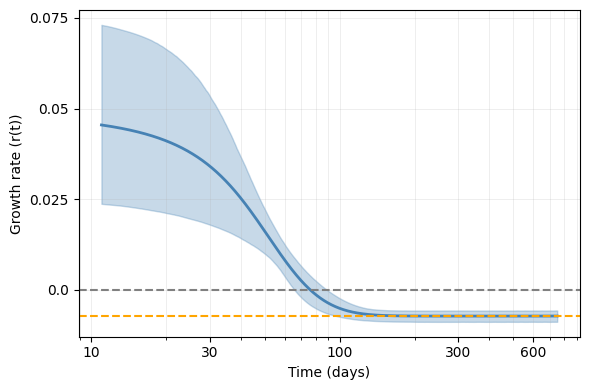

In [15]:
# Define the growth rate function in terms of M (avoid name clash with variable 'r')
def r_m_time(lamda, M, M_stable, K):
    """Instantaneous logistic growth rate r(M) given parameters."""
    r = -(lamda) / (1.0 - (M_stable / K))
    return r * (1.0 - (M / K))

# Define the ODE function with signature (t, y, *args) required by solve_ivp
def ode_function(t, y, S, lamda, M_stable, K):
    M_val = y[0]
    dMdt = S + r_m_time(lamda, M_val, M_stable, K) * M_val
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
lamda = data_DDM.stan_variable('lambda')
M_stable = data_DDM.M_stable
K = data_DDM.K

# Compute S using posterior samples to get a representative mean source if desired
# This avoids mixing scalar means incorrectly.
S = data_DDM.stan_variable('lambda') * data_DDM.M_stable

M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(lamda), len(t_ev)))
for i in range(len(lamda)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(S[i], lamda[i], M_stable[i], K[i]))
    sol[i, :] = result.y[0]

# Extract solution and compute r(t)
r_t = np.zeros((len(t_ev), len(lamda)))
for i in range(len(lamda)):
    M_t = sol[i, :]
    r_t[:, i] = r_m_time(lamda[i], M_t, M_stable[i], K[i])

# Calculate statistics
r_m_mean = np.mean(r_t, axis=1)
r_m_lower = np.percentile(r_t, 2.5, axis=1)
r_m_upper = np.percentile(r_t, 97.5, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.plot(t_ev, r_m_mean, color='steelblue', linewidth=2)
axes.fill_between(t_ev, r_m_lower, r_m_upper, alpha=0.3, color='steelblue')
plt.axhline(y=0, color='grey', linestyle='--')
plt.axhline(y=-np.mean(data_DDM.stan_variable('lambda'), axis=0), color='orange', linestyle='--', label='Growth Rate')
plt.xscale('log')
# plt.yscale('log')
plt.yticks([0.0, 0.025, 0.05, 0.075], [0.0, 0.025, 0.05, 0.075])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
axes.set_ylabel('Growth rate (r(t))')
axes.set_xlabel('Time (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

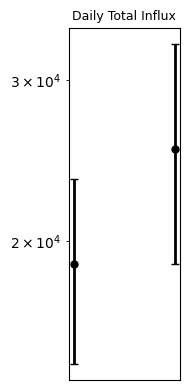

In [16]:
# Compare parameters between the two models ,"Lamda", "M_stable", "K"
# lamda_dependent = data_neutral.stan_variable('delta') - data_neutral.stan_variable('rho')
# M_stable_dependent = data_neutral.stan_variable('M_stable')
# K_dependent = data_neutral.stan_variable('K')

lamda_independent = data_DDM.stan_variable('lambda')
M_stable_independent = data_DDM.stan_variable('M_stable')
K_independent = data_DDM.stan_variable('K')
s = lamda_independent * M_stable_independent
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(2, 4))

# Plot daily influx for each model with different colors
colors = ['black', 'black']
models = [s, S_chimera ]
labels = ['Constant influx','Constant influx']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=3, markersize=5, elinewidth=2, 
                label=label)

# ax.set_ylabel('Net loss rate', fontsize=15)
# ax.set_xlabel('Model', fontsize=15)
ax.set_title('Daily Total Influx', fontsize=9)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yscale('log')
# ax.set_ylim(1e4, 3e4)
# ax.set_yticks([1.5e4, 2e4, 2.5e4])
# ax.set_xticks(range(2))
# ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
#ax.legend()

plt.tight_layout()
plt.show()




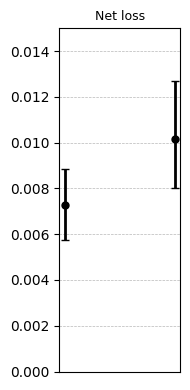

In [23]:
lamda_independent = data_DDM.stan_variable('lambda')
M_stable_independent = data_DDM.stan_variable('M_stable')
K_independent = data_DDM.stan_variable('K')
lambda_samples = delta_samples - rho_samples
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(2, 4))

# Plot daily influx for each model with different colors
colors = ['black', 'black']
models = [lamda_independent, lambda_samples ]
labels = ['Constant influx','Constant influx']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=3, markersize=5, elinewidth=2, 
                label=label)

# ax.set_ylabel('Net loss rate', fontsize=15)
# ax.set_xlabel('Model', fontsize=15)
ax.set_title('Net loss', fontsize=9)
ax.set_xticklabels([])
ax.set_xticks([])
# ax.set_yscale('log')
ax.set_ylim(0, 0.015)
# ax.set_yticks([1.5e4, 2e4, 2.5e4])
# ax.set_xticks(range(2))
# ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
#ax.legend()

plt.tight_layout()
plt.show()

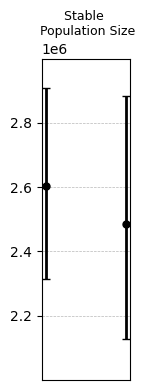

In [17]:
# Compare parameters between the two models ,"Lamda", "M_stable", "K"
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))

# Plot daily influx for each model with different colors
colors = ['black', 'black']
models = [M_stable_independent, M_stable_samples[:,0] ]
labels = ['Stable Population Size', 'Stable Population Size']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=3, markersize=5, elinewidth=2, 
                label=label)

# ax.set_ylabel('Net loss rate', fontsize=15)
# ax.set_xlabel('Model', fontsize=15)
ax.set_title('Stable \n Population Size', fontsize=9)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_ylim(2e6, 3e6)
ax.set_yticks([2.2e6, 2.4e6, 2.6e6, 2.8e6])
# ax.set_xticks(range(2))
# ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
#ax.legend()

plt.tight_layout()
plt.show()

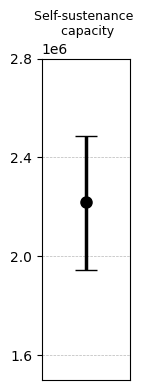

In [18]:
# Compare parameters between the two models ,"Lamda", "M_stable", "K"
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))

# Plot daily influx for each model with different colors
colors = ['black']
models = [K_independent]
labels = ['Self-sustenance Capacity']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

# ax.set_ylabel('Net loss rate', fontsize=15)
# ax.set_xlabel('Model', fontsize=15)
ax.set_title('Self-sustenance \n capacity', fontsize=9)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_ylim(1.5e6, 2.5e6)
ax.set_yticks([1.6e6, 2.0e6, 2.4e6, 2.8e6])
# ax.set_xticks(range(2))
# ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
#ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'M_stable_dependent' is not defined

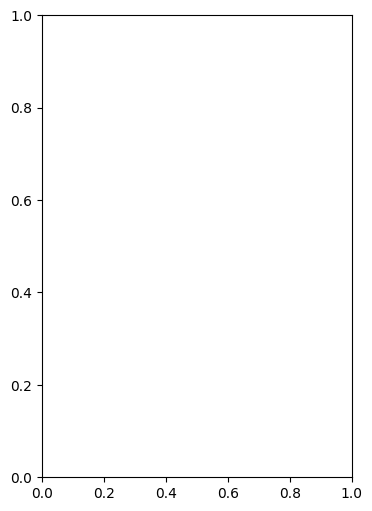

In [19]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange']
models = [M_stable_dependent, M_stable_independent]
labels = ['T1 Precursor driven', 'T1 independent']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Counts', fontsize=15)
# ax.set_xlabel('Model', fontsize=15)
ax.set_title('M_stable', fontsize=16)
ax.set_xticks(range(2))
ax.set_ylim(1.5*1e6, 3*1e6)
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
# ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Plot turnover time 

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=3, markersize=5, elinewidth=1)
    
fig, ax = plt.subplots(1, 1, figsize=(1.2, 4))
plot_with_error_bars(turnover_time_T2, '' ,'black', ax)
ax.set_ylim(100, 550)
ax.set_yticks([100, 200, 300, 400, 500])
ax.set_yticklabels(['100', '', '300', '', '500'], fontsize=10)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Turnover \n Time', fontsize=9)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
plt.tight_layout()
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Turnover_Time_T2.pdf', dpi=300)
plt.show()

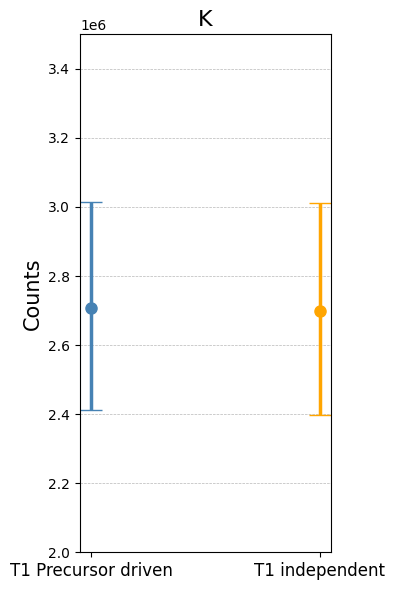

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange']
models = [K_dependent, K_independent]
labels = ['T1 Precursor driven', 'T1 independent']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Counts', fontsize=15)
# ax.set_xlabel('Model', fontsize=15)
ax.set_title('K', fontsize=16)
ax.set_xticks(range(2))
ax.set_ylim(2*1e6, 3.5*1e6)
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
# ax.legend()

plt.tight_layout()
plt.show()

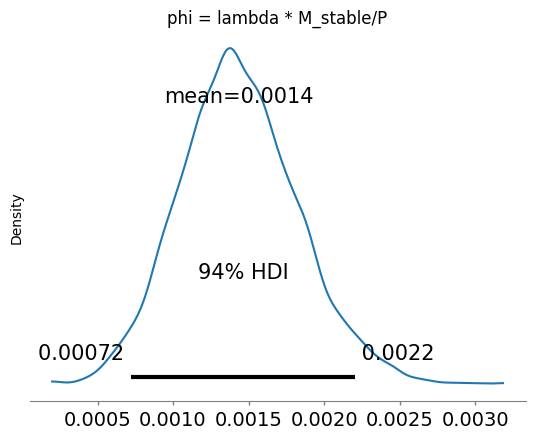

In [ ]:
lamda_samples = data_neutral.stan_variable('delta') - data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('M_stable')

phi = lamda_samples * M_stable_samples/ 1298783 

# Plot the posterior distribution for S
az.plot_posterior(phi, kind='kde')

# Remove X from the plot

plt.ylabel('Density')
plt.title('phi = lambda * M_stable/P')
plt.show()

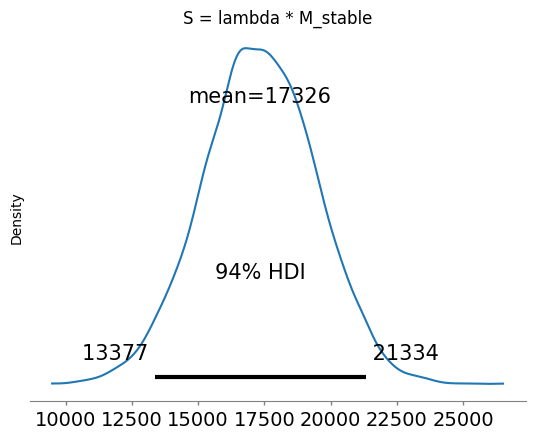

In [ ]:
lamda_samples = data_neutral_independent.stan_variable('lamda')
M_stable_samples = data_neutral_independent.stan_variable('M_stable')

S = lamda_samples * M_stable_samples

# Plot the posterior distribution for S
az.plot_posterior(S, kind='kde')

# Remove X from the plot

plt.ylabel('Density')
plt.title('S = lambda * M_stable')
plt.show()

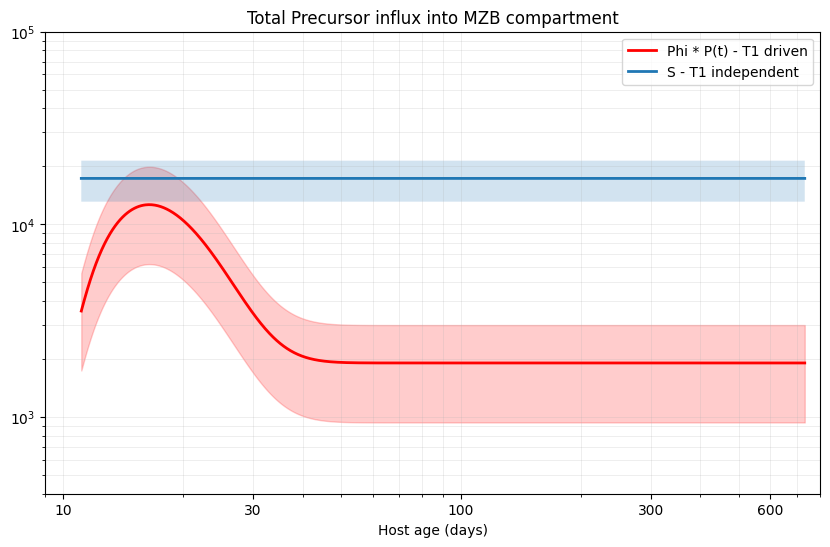

In [ ]:
# Plot phi* P(t)

def P(t):
    theta_0 = np.exp(14.1)
    nu = 0.31
    n = 2.0
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

plt.figure(figsize=(10, 6))
plt.plot(ts2, np.mean(phi[:, None] * P(ts2), axis=0), color='red', linewidth=2, label='Phi * P(t) - T1 driven')
plt.fill_between(ts2, np.percentile(phi[:, None] * P(ts2), 2.5, axis=0), np.percentile(phi[:, None] * P(ts2), 97.5, axis=0), alpha=0.2, color='red')

# Plot S as a horizontal line with its 95% CI
mean_S = np.mean(S)
lower_S = np.percentile(S, 2.5)
upper_S = np.percentile(S, 97.5)
plt.plot(ts2, np.full_like(ts2, mean_S), linewidth=2, label='S - T1 independent')
plt.fill_between(ts2, lower_S, upper_S, alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(4*1e2, 1e5)                
plt.xlim(9, 800)
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
# plt.ylabel('Total influx rate (cells/day)')
plt.title('Total Precursor influx into MZB compartment')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()  

In [ ]:
# Plot netloss with respect to M 
lamda_dependent = data_neutral.stan_variable('delta') - data_neutral.stan_variable('rho')
delta = np.mean(data_neutral.delta, axis=0)
r = np.mean(data_neutral.rho, axis=0) / (1 - (np.mean(data_neutral.M_stable, axis=0) / np.mean(data_neutral.K, axis=0)))
def netloss(M):
    return delta + r * (1 - (M / np.mean(data_neutral.K, axis=0)))

lamda_independent = data_neutral_independent.stan_variable('lamda')
delta = lamda_independent
r = np.mean(data_neutral_independent.rho, axis=0) / (1 - (np.mean(data_neutral_independent.M_stable, axis=0) / np.mean(data_neutral_independent.K, axis=0)))
def netloss1(M):
    return delta + r * (1 - (M / np.mean(data_neutral_independent.K, axis=0)))

# Carrying Capacity
K = np.mean(data_neutral.K, axis=0)
M = np.arange(0, np.exp(15), 1)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(M, netloss(M))
axes.plot(M, netloss1(M))
# Removed fill_between for quantiles since only mean is available
plt.axvline(x=np.mean(data_neutral.K, axis=0), color='red', linestyle='--', label='Carrying parameter (K)')
plt.axvline(x=np.mean(data_neutral.M_stable, axis=0), color='green', linestyle='--', label='Stable Population Size (M_stable)')
plt.axhline(y=np.mean(lamda_dependent), color='orange', linestyle='--', label='Net loss Rate')
plt.axhline(y=np.mean(data_neutral.rho, axis=0), color='grey', linestyle='--', label='Division Rate')
plt.axhline(y=np.mean(data_neutral.delta, axis=0), color='blue', linestyle='--', label='Death Rate')
# plt.axvline(x=K_0, color='blue', linestyle='--', label='Carrying Capacity (K_0)')   
# axes.set_ylim(0, 0.02)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xscale('log')
# axes.set_xlim(0, 750)
# axes.set_xticks([10, 30, 50, 100, 150, 200])
# axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel('Net loss (b(M))')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.legend(loc='upper right')
# axes.set_title('Total number of source cells into MZ (/day)')
plt.tight_layout()
plt.show()

AttributeError: Unknown variable name: delta
Available variables are sigma, lamda, M_stable, K, rho, y1, k_hat, totalMz_mean, MZ_counts_mean, parms, k_hat_pred1, MZ_counts_pred, loss_rate, log_lik_Mz, residuals_Mz

In [ ]:
# # Plot rho(M) with respect to M 


# # Plot rho(M) with respect to M 

# def r_m_samples(M):
#     # Compute r_m for each posterior sample
#     r_samples = data_neutral.rho / (1 - (data_neutral.M_stable / data_neutral.K))
#     K_samples = data_neutral.K
    
#     # Broadcast M across all samples
#     M_broadcast = M[:, np.newaxis]  
#     K_broadcast = K_samples[np.newaxis, :]  
#     r_broadcast = r_samples[np.newaxis, :]  
    
#     return r_broadcast * (1 - (M_broadcast / K_broadcast))

# M = np.arange(0, np.exp(15), 1)
# r_m_all_samples = r_m_samples(M)

# # Compute mean and quantiles
# r_m_mean = np.mean(r_m_all_samples, axis=1)
# r_m_lower = np.quantile(r_m_all_samples, 0.025, axis=1)
# r_m_upper = np.quantile(r_m_all_samples, 0.975, axis=1)

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(M, r_m_mean)
# plt.fill_between(M, r_m_lower, r_m_upper, alpha=0.3)
# plt.axvline(x=np.mean(data_neutral.K), color='red', linestyle='--', label='Carrying parameter (K)')
# plt.axvline(x=np.mean(data_neutral.M_stable), color='green', linestyle='--', label='Stable Population Size (M_stable)')
# plt.axhline(y=np.mean(data_neutral.rho), color='orange', linestyle='--', label='Division Rate')
# plt.axhline(y=0, color='grey', linestyle='--')

# axes.set_ylabel('Logistic growth rate (b(M))')
# axes.set_xlabel('MZ counts')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# axes.legend(loc='upper right')
# plt.tight_layout()
# plt.show()

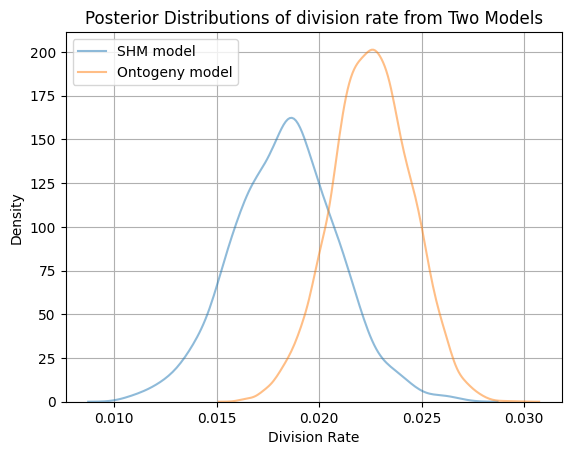

In [ ]:
sns.kdeplot(data_SHM.rho, label='SHM model', alpha=0.5)
sns.kdeplot(data_neutral.rho, label='Ontogeny model', alpha=0.5)

plt.xlabel('Division Rate')
plt.ylabel('Density')
plt.title('Posterior Distributions of division rate from Two Models')
plt.legend()
plt.grid(True)
plt.show()

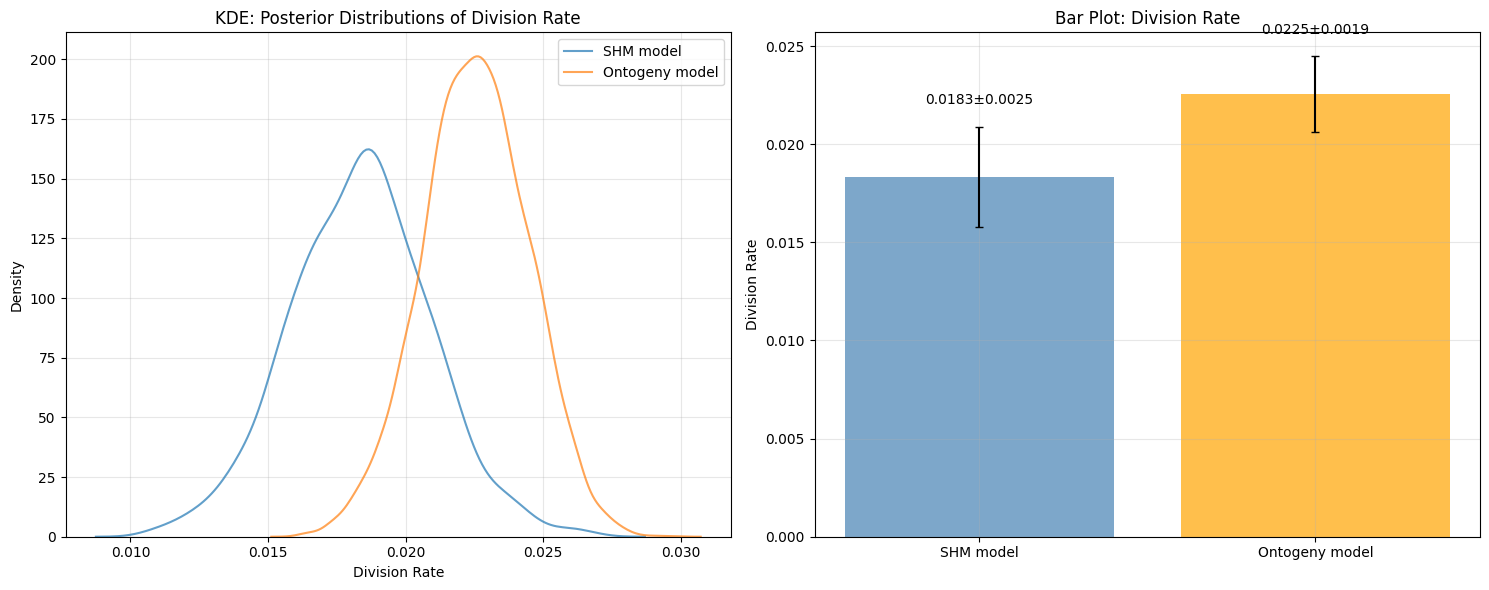

In [ ]:
# Create subplots with KDE and bar plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# KDE plot (left subplot)
sns.kdeplot( data_SHM.rho, label='SHM model', alpha=0.7, ax=ax1)
sns.kdeplot(data_neutral.rho, label='Ontogeny model', alpha=0.7, ax=ax1)
ax1.set_xlabel('Division Rate')
ax1.set_ylabel('Density')
ax1.set_title('KDE: Posterior Distributions of Division Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar plot comparing means and confidence intervals (right subplot)
models = ['SHM model', 'Ontogeny model']
means = [np.mean(data_SHM.rho), np.mean(data_neutral.rho)]
stds = [np.std(data_SHM.rho), np.std(data_neutral.rho)]

bars = ax2.bar(models, means, yerr=stds, capsize=3, alpha=0.7, 
               color=['steelblue', 'orange'])
ax2.set_ylabel('Division Rate')
ax2.set_title('Bar Plot: Division Rate')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.001,
             f'{mean:.4f}±{std:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

AttributeError: Unknown variable name: delta
Available variables are y0_Log, kappa_0, sigma, rho, phi, k_hat, totalMz_mean, Nfd_mean, Kid_mean, Kih_mean, MZ_counts_mean, donor_fractions_mean, host_ki_mean, donor_ki_mean, parms, initial_cond, y0, k_hat_pred1, k_hat_pred2, k_hat_pred3, MZ_counts_pred1, Nfd_pred1, host_ki_pred1, donor_ki_pred1, MZ_counts_pred2, Nfd_pred2, host_ki_pred2, donor_ki_pred2, MZ_counts_pred3, Nfd_pred3, host_ki_pred3, donor_ki_pred3, rho_inv, log_lik_Mz, log_lik_Nfd, log_lik_Kid, log_lik_Kih, residuals_Mz, residuals_Nfd, residuals_Kid, residuals_Kih

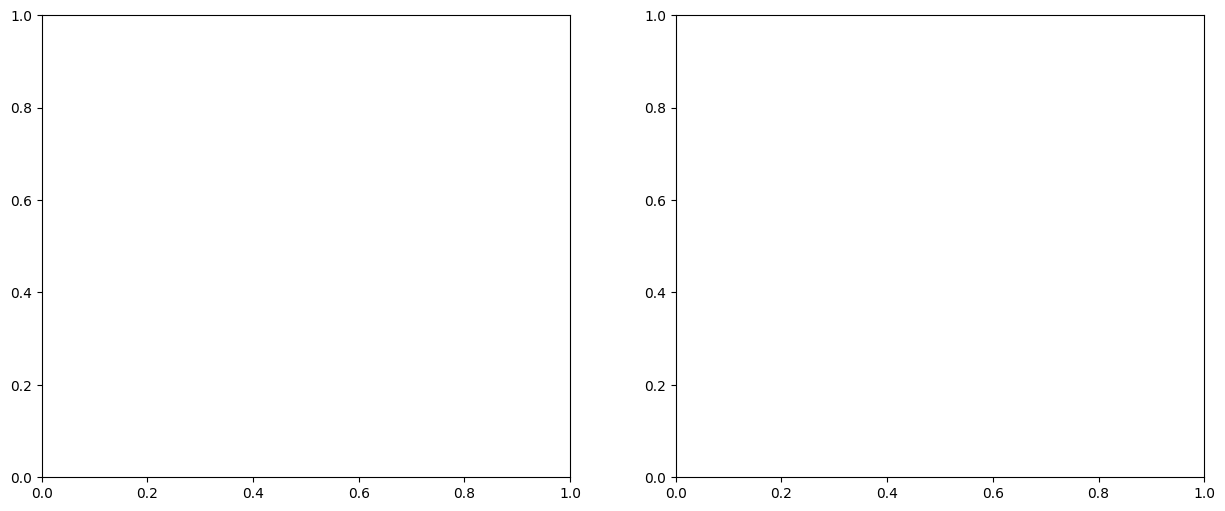

In [ ]:
# Create subplots with KDE and bar plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# KDE plot (left subplot)
sns.kdeplot(data_SHM.delta, label='SHM model', alpha=0.7, ax=ax1)
sns.kdeplot(data_neutral.delta, label='Ontogeny model', alpha=0.7, ax=ax1)
ax1.set_xlabel('Loss Rate')
ax1.set_ylabel('Density')
ax1.set_title('KDE: Posterior Distributions of Loss Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar plot comparing means and confidence intervals (right subplot)
models = ['SHM model', 'Ontogeny model']
means = [np.mean( data_SHM.delta), np.mean(data_neutral.delta)]
stds = [np.std( data_SHM.delta), np.std(data_neutral.delta)]

bars = ax2.bar(models, means, yerr=stds, capsize=5, alpha=0.7, 
               color=['steelblue', 'orange'])
ax2.set_ylabel('Loss Rate')
ax2.set_title('Bar Plot: Mean Loss Rate Comparison')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.001,
             f'{mean:.4f}±{std:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
lamda= data_neutral.stan_variable('delta') - data_neutral.stan_variable('rho')
az.plot_posterior(lamda, kind='kde')
plt.title('lamda= delta - rho')

In [ ]:
lamda= data_neutral.stan_variable('delta') - data_neutral.stan_variable('rho')

# Create subplots with KDE and bar plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# KDE plot (left subplot)
sns.kdeplot(df.lamda, label='SHM model', alpha=0.7, ax=ax1)
sns.kdeplot(lamda, label='Ontogeny model', alpha=0.7, ax=ax1)
ax1.set_xlabel('Net Loss Rate')
ax1.set_ylabel('Density')
ax1.set_title('KDE: Posterior Distributions of Net Loss Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar plot comparing means and confidence intervals (right subplot)
models = ['SHM model', 'Ontogeny model']
means = [np.mean(df.lamda), np.mean(lamda)]
stds = [np.std(df.lamda), np.std(lamda)]

bars = ax2.bar(models, means, yerr=stds, capsize=5, alpha=0.7, 
               color=['steelblue', 'orange'])
ax2.set_ylabel('Net Loss Rate')
ax2.set_title('Bar Plot: Mean Net Loss Rate Comparison')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.001,
             f'{mean:.4f}±{std:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()  

In [ ]:
# delta = data_neutral.stan_variable('lamda') + data_neutral.stan_variable('rho')
# az.plot_posterior(delta, kind='kde')
# plt.title('delta = lambda + rho')

In [ ]:
# delta = data_neutral.stan_variable('lamda') + data_neutral.stan_variable('rho')

# sns.kdeplot(df.delta, label='SHM model', alpha=0.5)
# sns.kdeplot(delta, label='Ontogeny model', alpha=0.5)

# plt.xlabel('Death Rate')
# plt.ylabel('Density')
# plt.title('Posterior Distributions of death rate from Two Models')
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# Get posterior samples for 'lambda' and 'M_stable'
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('M_stable')
K_samples = data_neutral.stan_variable('K')


alpha = rho_samples / (1 - (M_stable_samples / K_samples))

# Plot the posterior distribution for alpha
az.plot_posterior(alpha, kind='kde')

# Remove X from the plot

plt.ylabel('Density')
plt.title('alpha = rho / (1 - (M_stable / K))')
plt.show()

In [ ]:
lamda_samples = data_neutral.stan_variable('delta') - data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('M_stable')

phi = lamda_samples * M_stable_samples/ 1298783 

# Plot the posterior distribution for S
az.plot_posterior(phi, kind='kde')

# Remove X from the plot

plt.ylabel('Density')
plt.title('phi = lambda * M_stable/P')
plt.show()

In [ ]:
# # Get posterior samples for 'lambda' and 'M_stable'
# lambda_samples = data_neutral.stan_variable('lamda')
# M_stable_samples = data_neutral.stan_variable('M_stable')

# phi = lambda_samples * M_stable_samples/ 1298783 

# # Plot the posterior distribution for S
# az.plot_posterior(phi, kind='kde')

# # Remove X from the plot

# plt.ylabel('Density')
# plt.title('phi = lambda * M_stable/P')
# plt.show()


In [ ]:
r = np.mean(data_neutral.rho, axis=0) / (1 - (np.mean(data_neutral.M_stable, axis=0) / np.mean(data_neutral.K, axis=0)))
print(r)
def r_m(M):
    return r * (1 - (M / np.mean(data_neutral.K, axis=0)))

#cARRYING CAPACITY
K = np.mean(data_neutral.K, axis=0)
# delta = np.mean(data_neutral.lamda, axis=0) + np.mean(data_neutral.rho, axis=0)
# K_0 = K * (1 - (np.mean(data_neutral.rho, axis=0) / delta))

M = np.arange(0, np.exp(15), 1)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(M, r_m(M))
axes.fill_between(np.mean(data_neutral.MZ_counts_pred, axis=0), np.quantile(r_m, 0.025, axis=0), np.quantile(r_m, 0.975, axis=0), alpha=0.3)
plt.axvline(x=np.mean(data_neutral.K, axis=0), color='red', linestyle='--', label='Carrying parameter (K)')
plt.axvline(x=np.mean(data_neutral.M_stable, axis=0), color='green', linestyle='--', label='Stable Population Size (M_stable)')
plt.axhline(y=np.mean(data_neutral.rho), color='orange', linestyle='--', label='Division Rate')
plt.axhline(y=0, color='grey', linestyle='--')
# plt.axvline(x=K_0, color='blue', linestyle='--', label='Carrying Capacity (K_0)')   
# axes.set_ylim(0, 0.02)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xscale('log')
# axes.set_xlim(0, 750)
# axes.set_xticks([10, 30, 50, 100, 150, 200])
# axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel('Logistic growth rate (b(M))')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.legend(loc='upper right')
# axes.set_title('Total number of source cells into MZ (/day)')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(np.mean(data_neutral.MZ_counts_pred, axis=0), np.mean(data_neutral.source_rate, axis=0))
# axes.fill_between(np.mean(data_neutral.MZ_counts_pred, axis=0), np.quantile(data_neutral.source_rate, 0.025, axis=0), np.quantile(data_neutral.source_rate, 0.975, axis=0), alpha=0.3)
plt.axvline(x=np.mean(data_neutral.K, axis=0), color='red', linestyle='--', label='Carrying Capacity (K)')
plt.axvline(x=np.mean(data_neutral.M_stable, axis=0), color='green', linestyle='--', label='Stable Population Size (M_stable)')
plt.axhline(y=-0.0092, color='orange', linestyle='--', label='Loss Rate (lambda)')
# axes.set_ylim(0, 0.02)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xscale('log')
# axes.set_xlim(0, 750)
# axes.set_xticks([10, 30, 50, 100, 150, 200])
# axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel(' ')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.legend()
# axes.set_title('Total number of source cells into MZ (/day)')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts2, np.mean(data_neutral.source_rate, axis=0))
axes.fill_between(ts2, np.quantile(data_neutral.source_rate, 0.025, axis=0), np.quantile(data_neutral.source_rate, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.03)
# plt.ylim(1e1, 1e8)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
axes.set_xscale('log')
axes.set_xlim(0, 750)
axes.set_xticks([10, 30, 50, 100, 150, 200])
axes.set_xticklabels([10, 30,  50, 100, 150, 200])
# axes.set_ylabel('Source counts (/day)')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying r(M)')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(np.mean(data_neutral.MZ_counts_pred, axis=0), np.mean(data_neutral.loss_rate, axis=0))
axes.fill_between(np.mean(data_neutral.MZ_counts_pred, axis=0), np.quantile(data_neutral.loss_rate, 0.025, axis=0), np.quantile(data_neutral.loss_rate, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.02)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xscale('log')
# axes.set_xlim(0, 750)
# axes.set_xticks([10, 30, 50, 100, 150, 200])
# axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel(' ')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Total number of source cells into MZ (/day)')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, color = 'Red', label=' T1 Counts')
# sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, color = 'Red', legend=False)
# sns.scatterplot(data=df_new, x='Age at S1K', y='total_T2', alpha=0.85 ,s=85, color = 'Blue', label= 'T2 counts')
# sns.scatterplot(data=df_ont_T2, x='age.at.S1K', y='Transitional2', alpha=0.85, color = 'Blue',s=85, legend=False)
axes.plot(ts2, np.mean(data_neutral.loss_rate, axis=0))
axes.fill_between(ts2, np.quantile(data_neutral.loss_rate, 0.025, axis=0), np.quantile(data_neutral.loss_rate, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.03)
# plt.ylim(1e1, 1e8)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
axes.set_xscale('log')
axes.set_xlim(0, 750)
axes.set_xticks([10, 30, 50, 100, 150, 200])
axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel('Source counts (/day)')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying Source')
plt.tight_layout()
plt.show()

In [ ]:
# Rate of influx of T1 into MZ

# def phi(t, r_phi):
    # phi = 0.014
    # phi_var = phi / (1 + np.exp(-r_phi * (t-20)))
    # return phi_var
# def phi(t, r_phi):
#     if(t < 40):
#      r_phi = 0.017
#      phi = 0.014
#      phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.8))
#     else:
#       phi_var = 0.014
#     return(phi_var)

def phi(t, r_phi, alpha, t0):
    phi_value = 0.014  # Assuming phi is a constant value
    phi_var =  ((phi_value - alpha) / (1 + np.exp(-(r_phi) * (t- t0)))) + alpha
    return phi_var

def P(t):

    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

t = np.arange(11, 152, 1)

# influx_p = np.zeros((8000, 739))
# for i in range(0, 739):  # Ensure the loop does not exceed the bounds
#     # influx_p[:, i] = (phi(i + 11, data_neutral.r_phi, data_neutral.alpha) * P(i + 11)) / data_neutral.MZ_counts_pred[:, i]
#     influx_p[:, i] = (phi(i + 11, data_neutral.r_phi) * P(i + 11)) / data_neutral.MZ_counts_pred[:, i]
    

influx_rate = np.zeros((8000, 739))
for i in range(0, 739):  # Ensure the loop does not exceed the bounds
    influx_rate[:, i] = phi(i + 11, data_neutral.r_phi, data_neutral.alpha, data_neutral.t0) 
 


# # influx = np.array(influx)
# print(len(influx_p))
# print(influx_p.shape)
# # print(np.quantile(influx_p, 0.025, axis=0))
# # print(np.quantile(influx_p, 0.975, axis=0))

# # Plot precursor influx with 95% CI

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts1, np.mean(influx_p, axis=0))
# axes.fill_between(ts1, np.quantile(influx_p, 0.025, axis=0), np.quantile(influx_p, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.15)
# # axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# # axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xlim(10, 750)
# axes.set_xticks([50, 200, 350, 500])
# axes.set_xticklabels([50, 200, 350, 500])
# axes.set_ylabel('Fraction of influx')
# axes.set_xlabel('Host Age (days)')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# axes.set_title('Proportion of influx of TA44.1 precursor cells into the MZ pool')
# plt.tight_layout()
# plt.show()


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ts1= np.arange(11, 152, 1)
axes.plot(ts1, np.mean(influx_rate, axis=0))
axes.fill_between(ts1, np.quantile(influx_rate, 0.025, axis=0), np.quantile(influx_rate, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
axes.set_xscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xlim(0, 800)
axes.set_xticks([ 11, 40, 200, 400, 600])
axes.set_xticklabels([ 11, 40, 200, 400, 600])
axes.set_ylabel('Fraction of influx')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying influx rate')
plt.tight_layout()
plt.show()